# Image Denoising with Pretrained Diffusion Model

This notebook demonstrates an image denoising workflow:

1. Load and visualize a clean test image from the `truth` dataset.
2. Synthetically corrupt it with noise using helper utilities.
3. Use a pretrained denoising / image-to-image diffusion model from Hugging Face to recover a clean image.
4. Visually compare the original, noisy, and denoised outputs and compute a basic PSNR metric.

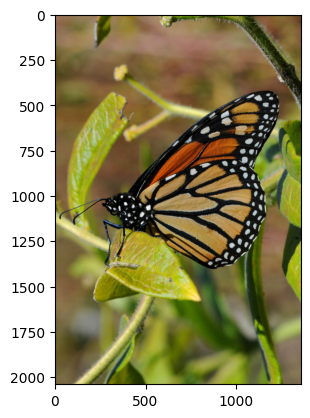

In [ ]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from diffusers import StableDiffusionImg2ImgPipeline
from PIL import Image
import torch

from helper import utils

In [ ]:
# Select a test image from the `truth` folder
path_to_test_image = Path(Path.cwd().parent, "data", "truth", "0006.png")

# Display the clean image
utils.display_image(path_to_test_image, path=True)

# Create a noisy version using the helper
noisy_image = utils.add_noise(str(path_to_test_image))
utils.display_image(noisy_image)

In [ ]:
# Utility: display multiple images side by side for quick comparison

def show_side_by_side(images, titles=None, figsize=(15, 5)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(1, n, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if titles:
            plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()


# Convert clean and noisy images to OpenCV arrays for later metrics
clean_img_bgr = cv2.imread(str(path_to_test_image))
noisy_img_bgr = noisy_image.copy()

show_side_by_side(
    [clean_img_bgr, noisy_img_bgr],
    titles=["Clean (Truth)", "Noisy Input"],
)

In [ ]:
# Load a pretrained image-to-image diffusion pipeline for denoising
# You can change the model name if desired; this one is relatively lightweight.

model_id = "runwayml/stable-diffusion-v1-5"

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
)
pipe = pipe.to(device)

# Use a neutral prompt so the model focuses on denoising/cleaning
prompt = "high quality clean photo, detailed, sharp"

# Convert noisy OpenCV image (BGR) to PIL RGB
noisy_rgb = cv2.cvtColor(noisy_img_bgr, cv2.COLOR_BGR2RGB)
noisy_pil = Image.fromarray(noisy_rgb)

# Run the pipeline with relatively low strength so the structure is preserved
with torch.autocast(device) if device == "cuda" else torch.no_grad():
    result = pipe(
        prompt=prompt,
        image=noisy_pil,
        strength=0.4,
        guidance_scale=7.5,
        num_inference_steps=30,
    )

denoised_pil = result.images[0]
denoised_bgr = cv2.cvtColor(np.array(denoised_pil), cv2.COLOR_RGB2BGR)

show_side_by_side(
    [noisy_img_bgr, denoised_bgr, clean_img_bgr],
    titles=["Noisy", "Denoised (SD Img2Img)", "Clean (Truth)"],
    figsize=(18, 6),
)

In [ ]:
# Simple PSNR metric to quantify denoising performance

def psnr(img1, img2):
    # Assumes uint8 images with same shape
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)
    if mse == 0:
        return float("inf")
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

psnr_noisy = psnr(clean_img_bgr, noisy_img_bgr)
psnr_denoised = psnr(clean_img_bgr, denoised_bgr)

print(f"PSNR (clean vs noisy):    {psnr_noisy:.2f} dB")
print(f"PSNR (clean vs denoised): {psnr_denoised:.2f} dB")